## Purpose

This exploratory analysis evaluates casino activity to identify where revenue is created, where losses are concentrated, and how casino, game, player, and game-mix patterns contribute to financial performance. The objective is to move beyond headline revenue by separating scale, efficiency, concentration, payout risk, and game-design characteristics.

## What Was Done

- Established a data-quality and financial baseline by validating completeness, checking for invalid financial values, and confirming that revenue equals total wager less total payout.
- Profiled the distribution of wagers, payouts, revenue, and spins to identify skew, loss frequency, and extreme activity outcomes.
- Measured activity and revenue concentration across casinos, games, players, and game types.
- Ranked casinos and games by total revenue and by revenue per spin, applying a 1,000-spin threshold for per-spin comparisons.
- Calculated RTP, margin, revenue per spin, player counts, and daily revenue movement to distinguish profitability from payout-driven risk.
- Linked leading casinos to the leading revenue and loss-driver games to test whether casino outcomes are associated with their game mix.
- Tested theme and mechanic associations by game type using one record per game, Fisher's exact tests, and false-discovery-rate correction to identify characteristic design features.

## Why This Approach

Casino performance is not explained by a single metric. Total revenue identifies financial scale, revenue per spin measures efficiency, RTP and margin show payout behaviour, and concentration analysis highlights dependency on a small number of entities. Combining these views with game-level theme and mechanic analysis provides a more robust assessment of performance, risk, and portfolio composition than ranking casinos or games by activity alone.

## Key Findings

- The portfolio generated 10.86B in revenue from 240.79B in wagers, with a 4.51% overall margin and 95.49% RTP.
- Performance is highly uneven: 21.91% of activity records are loss-making, while a relatively small number of high-value outcomes drive much of the variation.
- Revenue is concentrated among casinos: the top 10 account for 66.89% of total revenue. Casino activity and game activity are also concentrated, while player activity is widely dispersed.
- Game IDs 6012 and 4701 are the largest revenue contributors, whereas game ID 5635 is the largest loss driver. Several large loss-driver games have RTP above 100%, meaning payouts exceeded wagers over the observed period.
- Revenue-leading casinos show greater overlap with revenue-leading games than loss-making casinos show with loss-driver games. This indicates that loss outcomes are more dependent on casino-specific game mixes and/or isolated payout events.
- Theme and mechanic patterns differ materially by game type. Game type 31 has the strongest observed signatures, including theme_107 in 63.2% of its games and mech_134 in 92.1%, compared with 3.6% and 2.6% overall respectively.
- Game type 25 also has a distinct design profile: mechanics 48 and 128 are more than 22 times as prevalent as in the eligible game population, alongside several over-represented themes.
- The data covers two reporting dates only. The observed fall in daily revenue on 23 June is therefore a short-term movement, not evidence of a sustained trend.

> Overall, the analysis shows a profitable portfolio with concentrated revenue, material record-level volatility, and loss exposure driven by a smaller group of high-payout games and casino-specific game mixes. It also identifies distinct theme and mechanic signatures in game types 25 and 31.

# Load Cleaned Data

- Data Wrangler plugin confirmed that there is no missing data within any columns

In [28]:
import duckdb

con = duckdb.connect(
    r"..\data-modeling\target\adp_assessment.duckdb",
    read_only=True,
)

df = con.sql("select * from fct_activity").df()
con.close()

df.head()

,activity_date,casino_id,player_id,game_id,game_type,total_wager_base,total_payout_base,revenue,total_spins,go_live_date,...,mech_188,mech_189,mech_190,mech_191,mech_192,mech_193,mech_194,mech_195,mech_196,mech_197
0,2026-06-22,208,2469448,5831,38,84809.572549,103926.225703,-19116.653154,127,2026-05-15,...,0,0,0,0,0,0,0,0,0,0
1,2026-06-22,208,2469448,4735,38,13674.039437,6815.279225,6858.760212,56,2026-05-29,...,0,0,0,0,0,0,0,0,0,0
2,2026-06-22,208,2469448,3451,38,420176.776104,442435.661296,-22258.885192,514,2026-06-01,...,1,0,0,0,0,0,0,0,0,0
3,2026-06-22,208,2469448,6624,38,197382.120274,224390.389760,-27008.269485,200,2026-05-18,...,1,0,0,0,0,0,0,0,0,0
4,2026-06-22,208,2469448,5369,38,53480.425717,36529.966072,16950.459645,186,2025-07-31,...,1,0,0,0,0,0,0,0,0,0



## Activity Measure Profile

Question: Which financial measures are dominating the activity data, and how often are they zero or negative?

This cell summarizes the main operational metrics for the dataset:
- total wager
- total payout
- revenue
- total spins

It calculates totals, averages, medians, variability, and the share of records that are zero or negative so the business can quickly see whether the activity profile is healthy, noisy, or dominated by a few extreme values. This is more useful than a generic five-number summary because the revenue and wager distributions are highly skewed and need business-focused interpretation.

> the goal is to understand the shape and risk of the core financial measures before drilling into casinos and games.

In [ ]:
import pandas as pd

measure_columns = [
    "total_wager_base",
    "total_payout_base",
    "revenue",
    "total_spins",
]

measure_profile = pd.DataFrame(index=measure_columns)
measure_profile["total"] = df[measure_columns].sum()
measure_profile["mean"] = df[measure_columns].mean()
measure_profile["median"] = df[measure_columns].median()
measure_profile["std_dev"] = df[measure_columns].std()
measure_profile["minimum"] = df[measure_columns].min()
measure_profile["maximum"] = df[measure_columns].max()
measure_profile["zero_rate_pct"] = (
    (df[measure_columns] == 0).mean() * 100
)
measure_profile["negative_rate_pct"] = (
    (df[measure_columns] < 0).mean() * 100
)
measure_profile = measure_profile.round(2)

measure_profile

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_columns = [
    ("total", "Total value", "#2E8B57"),
    ("median", "Median value", "#4C78A8"),
    ("std_dev", "Standard deviation", "#F58518"),
]

figure, axes = plt.subplots(4, 1, figsize=(15, 12))

for axis, (column_name, title, color) in zip(axes[:3], plot_columns):
    values = measure_profile[column_name]
    transformed_values = np.sign(values) * np.log1p(np.abs(values))
    bars = axis.barh(values.index, transformed_values, color=color, alpha=0.85)
    axis.set_title(title, weight="bold")
    axis.set_xlabel("Signed-log scale")
    axis.grid(True, axis="x", linestyle="--", alpha=0.3)

    for bar, value in zip(bars, values):
        axis.text(
            bar.get_width() + (0.03 if value >= 0 else -0.03),
            bar.get_y() + bar.get_height() / 2,
            f"{value:,.2f}",
            va="center",
            ha="left" if value >= 0 else "right",
            fontsize=9,
        )

rate_values = measure_profile[["zero_rate_pct", "negative_rate_pct"]]
rate_values.plot(
    kind="barh",
    ax=axes[3],
    color=["#9B59B6", "#C0392B"],
    alpha=0.85,
)
axes[3].set_title("Zero and negative rates", weight="bold")
axes[3].set_xlabel("Percentage of records")
axes[3].grid(True, axis="x", linestyle="--", alpha=0.3)
axes[3].legend(title="Rate", frameon=False)

figure.suptitle("Activity Measure Profile", fontsize=16, weight="bold")
figure.tight_layout()
plt.show()

## Key insights

- Total wagering is much larger than payouts, but the operating margin is still small relative to the scale of the book:
  - total wager: 240,791,200,000
  - total payout: 229,927,800,000
  - revenue: 10,863,500,000

- Revenue is highly uneven:
  - median revenue is only 3,445.79, while the mean is 11,155.42
  - standard deviation is 666,612.67, which shows very large swings and a skewed distribution
  - negative revenue occurs in 21.91% of rows, so loss-making activity is a regular part of the portfolio

- Payouts are more volatile than wagers:
  - payout median is 12,914.66 vs wager median 23,361.26
  - maximum payout reaches 924,412,200, which is much larger than the maximum wager 786,329,000
  - payout zero-rate is 7.18%, meaning a meaningful share of records have no payout at all

- Spin activity is lightweight and frequent:
  - average spins per record is 130.38
  - median is 43
  - maximum is 23,069, which suggests a small number of very high-spin sessions are driving the tail

- There is no zero or negative wager count, which means every record is a valid wager event; the losses are concentrated in the payout/revenue side, not in the wager volume itself.

> Overall, the business generates positive total revenue, but individual activity is highly variable: loss-making records are common and a small number of extreme outcomes account for much of the distribution's spread.

## Activity Measure Profile

Question: What are we trying to understand about the core activity metrics before we investigate casinos and games?

This cell sets the baseline for the analysis. It summarises the main operating measures in the dataset so we can understand the scale, spread, and risk of the activity before drilling into segment-level performance. The goal is to establish whether the portfolio is broadly stable or whether a small number of extreme outcomes are creating the overall financial pattern.

We do this by checking:
- total wager
- total payout
- revenue
- total spins

and looking at their totals, averages, medians, variability, and the share of zeros and negatives. This gives us a clean foundation for later questions about which casinos, games, or game types are contributing the most revenue or loss.

> The purpose is not to explain the data yet, but to define the operating baseline that guides the deeper investigation.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

histogram_columns = [
    "total_wager_base",
    "total_payout_base",
    "revenue",
    "total_spins",
]


def signed_log(value):
    return np.sign(value) * np.log1p(np.abs(value))


def inverse_signed_log(value):
    return np.sign(value) * np.expm1(np.abs(value))


figure, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flat

for axis, column_name in zip(axes, histogram_columns):
    values = df[column_name].dropna()
    transformed_values = signed_log(values.to_numpy())
    quartiles = values.quantile([0.25, 0.50, 0.75])

    axis.hist(
        transformed_values,
        bins="auto",
        color="#4C78A8",
        alpha=0.82,
        edgecolor="white",
    )

    for percentile, color, label in [
        (0.25, "#F58518", "Q1"),
        (0.50, "#54A24B", "Median"),
        (0.75, "#E45756", "Q3"),
    ]:
        transformed_quartile = signed_log(quartiles.loc[percentile])
        axis.axvline(
            transformed_quartile,
            color=color,
            linestyle="--",
            linewidth=1.8,
            label=label,
        )

    axis.xaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{inverse_signed_log(value):,.0f}")
    )
    axis.set_title(column_name, fontsize=12, weight="bold")
    axis.set_xlabel("Actual value, signed-log spacing")
    axis.set_ylabel("Frequency")
    axis.tick_params(axis="x", labelrotation=35)
    axis.grid(True, axis="y", linestyle="--", alpha=0.3)
    axis.legend(frameon=False, fontsize=9)

    axis.text(
        0.98,
        0.95,
        f"Median: {quartiles.loc[0.50]:,.0f}\n"
        f"Middle 50%: {quartiles.loc[0.25]:,.0f} to {quartiles.loc[0.75]:,.0f}",
        transform=axis.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "#D9D9D9"},
    )

figure.suptitle("Activity Measure Distributions", fontsize=16, weight="bold")
figure.tight_layout()
plt.show()

## Key takeaways and business meaning

The raw profile shows that the business is operating at a large scale, but the distribution is highly uneven:
- total wager is 240.8B, total payout is 229.9B, and total revenue is 10.9B
- revenue has a mean of 11,155 but a median of 3,446, indicating a skewed distribution driven by a subset of high-value outcomes
- 21.91% of revenue rows are negative, so loss-making activity is common rather than exceptional
- payout has a 7.18% zero-rate, showing a meaningful share of records with no payout
- total spins are much smaller per record on average, with a median of 43 and a mean of 130, suggesting a long tail of high-spin records

> Overall, the portfolio is profitable in aggregate, but performance is structurally uneven: many individual records are loss-making, while a smaller number of high-value outcomes create much of the observed variation.

## Activity concentration by identifier

**Research question:** Is activity spread across many casinos, players, games, and game types, or concentrated in a small number of them?

This cell counts the unique values for each identifier and calculates the share of records held by the most common values. The charts show the top 10 identifiers by activity share.

**Rationale:** Concentration helps identify whether a small number of entities could have an outsized effect on revenue, losses, and operational risk.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

id_columns = ["casino_id", "player_id", "game_id", "game_type"]
id_titles = {
    "casino_id": "Casino concentration",
    "player_id": "Player concentration",
    "game_id": "Game concentration",
    "game_type": "Game type concentration",
}

id_dashboard_summary = pd.DataFrame(index=id_columns)
id_dashboard_summary["unique_values"] = df[id_columns].nunique()
id_dashboard_summary["top_value"] = df[id_columns].mode(dropna=True).iloc[0]
id_dashboard_summary["top_value_share_pct"] = (
    df[id_columns].apply(lambda column: column.value_counts().iloc[0])
    / len(df)
    * 100
).round(2)

display(id_dashboard_summary)

figure, axes = plt.subplots(2, 2, figsize=(15, 10))

for axis, column_name in zip(axes.flat, id_columns):
    frequencies = df[column_name].value_counts().head(10).sort_values()
    shares = frequencies / len(df) * 100
    bars = axis.barh(frequencies.index.astype(str), shares, color="#4C78A8")

    axis.set_xscale("log")
    axis.set_title(id_titles[column_name], weight="bold")
    axis.set_xlabel("Share of activity records (%)")
    axis.grid(True, axis="x", linestyle="--", alpha=0.3)

    for bar, share in zip(bars, shares):
        axis.text(
            bar.get_width() * 1.08,
            bar.get_y() + bar.get_height() / 2,
            f"{share:.2f}%",
            va="center",
            fontsize=9,
        )

figure.suptitle("Activity Concentration by Identifier", fontsize=16, weight="bold")
figure.tight_layout()
plt.show()

## Key takeaways and business meaning

- **Casino activity is concentrated.** The top 10 casinos generate 61.51% of activity records, and casino_id 240 alone accounts for 9.97%. Performance monitoring should therefore prioritise these major casinos because changes in their activity can materially affect the portfolio.

- **Game activity is also concentrated.** The top 10 games account for 28.25% of records, with game_id 5369 contributing 4.45%. These games are the strongest candidates for deeper revenue, margin, and risk analysis because they have the greatest potential to influence overall results.

- **Player activity is widely spread.** The top 10 players account for only 0.13% of records. This reduces dependence on individual players at the portfolio level, although player-level outliers may still matter for specific game or casino risks.

- **The game-type mix is heavily dominated by one category.** Game type 38 represents 94.91% of all activity. Any overall result is therefore likely to reflect this game type, so comparisons with the smaller game types should be treated carefully.

> Overall, activity is concentrated among a limited set of casinos and games, while player activity is widely dispersed. Game type 38 dominates the portfolio, so it has the strongest influence on the aggregate activity pattern.

## Revenue attribution by casino and game

**Investigative question:** Which casinos and games create the most revenue, and which ones are the main loss drivers?

This cell groups activity by casino and game, then calculates total revenue, wager, payout, activity count, and share of total revenue. It ranks the top and bottom 10 performers and visualises their financial contribution.

**Rationale:** High activity does not always mean high value. Comparing revenue with wager and payout identifies the casino and game segments that create the largest gains or absorb the most margin.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def build_revenue_attribution(data, group_column):
    grouped = (
        data.groupby(group_column, as_index=False)
        .agg(
            total_revenue=("revenue", "sum"),
            total_wager=("total_wager_base", "sum"),
            total_payout=("total_payout_base", "sum"),
            activity_count=("revenue", "size"),
        )
    )
    grouped["revenue_share_pct"] = (
        grouped["total_revenue"] / data["revenue"].sum() * 100
    ).round(2)
    return grouped


def format_currency_axis(value, _):
    absolute_value = abs(value)
    if absolute_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:.1f}B"
    if absolute_value >= 1_000_000:
        return f"{value / 1_000_000:.0f}M"
    if absolute_value >= 1_000:
        return f"{value / 1_000:.0f}K"
    return f"{value:.0f}"

casino_revenue = build_revenue_attribution(df, "casino_id")
game_revenue = build_revenue_attribution(df, "game_id")

ranking_tables = {
    "Top casinos by revenue": casino_revenue.nlargest(10, "total_revenue"),
    "Casino loss drivers": casino_revenue.nsmallest(10, "total_revenue"),
    "Top games by revenue": game_revenue.nlargest(10, "total_revenue"),
    "Game loss drivers": game_revenue.nsmallest(10, "total_revenue"),
}

for title, table in ranking_tables.items():
    print(title)
    display(table)

figure, axes = plt.subplots(4, 1, figsize=(16, 18))
plot_definitions = [
    (axes[0], casino_revenue.nlargest(10, "total_revenue"), "casino_id", "Top casinos by revenue", "#2E8B57"),
    (axes[1], casino_revenue.nsmallest(10, "total_revenue"), "casino_id", "Casino loss drivers", "#C0392B"),
    (axes[2], game_revenue.nlargest(10, "total_revenue"), "game_id", "Top games by revenue", "#2E8B57"),
    (axes[3], game_revenue.nsmallest(10, "total_revenue"), "game_id", "Game loss drivers", "#C0392B"),
]

for axis, table, label_column, title, color in plot_definitions:
    plot_table = table.sort_values("total_revenue")
    bars = axis.barh(
        plot_table[label_column].astype(str),
        plot_table["total_revenue"],
        color=color,
        alpha=0.82,
    )
    axis.axvline(0, color="#333333", linewidth=1)
    axis.set_title(title, weight="bold")
    axis.set_ylabel(label_column.replace("_", " ").title())
    axis.set_xlabel("Revenue in base currency")
    axis.xaxis.set_major_formatter(FuncFormatter(format_currency_axis))
    axis.grid(True, axis="x", linestyle="--", alpha=0.3)

    for bar, value in zip(bars, plot_table["total_revenue"]):
        offset = max(abs(plot_table["total_revenue"]).max() * 0.01, 1)
        axis.text(
            value + (offset if value >= 0 else -offset),
            bar.get_y() + bar.get_height() / 2,
            f"{value:,.0f}",
            va="center",
            ha="left" if value >= 0 else "right",
            fontsize=8,
        )

figure.suptitle("Revenue Attribution: Contribution and Loss Drivers\n", fontsize=16, weight="bold")
figure.tight_layout()
plt.show()

## Key takeaways and business meaning

- **Casino revenue is highly concentrated.** The top 10 casinos create 66.89% of the total 10.86B revenue. Casino_id 277 is the largest contributor at 1.64B, followed by 240 at 1.11B. These casinos should be the first focus for commercial performance monitoring because changes in their results will materially affect the portfolio.

- **Activity volume and revenue are not the same.** Casino_id 240 has slightly more activity records than 277, but 277 generates substantially more revenue. This shows that record volume alone is not a reliable measure of value; margin and payout behaviour must be reviewed alongside activity.

- **Losses are concentrated in a few casino and game segments.** Casino_id 29 is the largest casino loss driver at -295.8M. Game_id 5635 is the largest game loss driver at -302.6M, despite only 2,314 activity records. Smaller-volume segments can therefore create disproportionate financial risk.

- **Game revenue is less concentrated than casino revenue.** The top 10 games contribute 31.67% of total revenue, led by game_ids 6012, 4701, 6417, 5614, and 5954. This gives the business a broader base of profitable games, but also makes it important to manage the largest loss-making games individually.

> The business should protect performance in the leading casinos and games, while prioritising a root-cause review of casino_id 29 and game_id 5635 to understand whether their losses are driven by payout behaviour, game design, or a small number of exceptional outcomes.

## Revenue and loss per spin

**Investigative question:** Which casinos and games generate the most revenue or loss for each spin played?

This cell aggregates revenue, payout, and spins by casino and game. It then calculates revenue per spin and compares the top and bottom 10 performers, excluding segments with fewer than 1,000 spins.

**Rationale:** Total revenue can be driven by volume alone. Revenue per spin controls for volume and identifies segments that are especially profitable or risky on each individual play.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def build_spin_velocity(data, group_column, minimum_spins=1000):
    grouped = (
        data.groupby(group_column, as_index=False)
        .agg(
            total_revenue=("revenue", "sum"),
            total_payout=("total_payout_base", "sum"),
            total_spins=("total_spins", "sum"),
            activity_count=("revenue", "size"),
        )
    )
    grouped = grouped[grouped["total_spins"] >= minimum_spins].copy()
    grouped["revenue_per_spin"] = (
        grouped["total_revenue"] / grouped["total_spins"]
    )
    grouped["payout_per_spin"] = (
        grouped["total_payout"] / grouped["total_spins"]
    )
    return grouped.sort_values("revenue_per_spin")


casino_spin_velocity = build_spin_velocity(df, "casino_id")
game_spin_velocity = build_spin_velocity(df, "game_id")

velocity_tables = {
    "Casinos making most revenue per spin": casino_spin_velocity.nlargest(10, "revenue_per_spin"),
    "Casinos losing most per spin": casino_spin_velocity.nsmallest(10, "revenue_per_spin"),
    "Games making most revenue per spin": game_spin_velocity.nlargest(10, "revenue_per_spin"),
    "Games losing most per spin": game_spin_velocity.nsmallest(10, "revenue_per_spin"),
}

for title, table in velocity_tables.items():
    print(title)
    display(table)

figure, axes = plt.subplots(4, 1, figsize=(16, 18))
plot_definitions = [
    (axes[0], casino_spin_velocity.nlargest(10, "revenue_per_spin"), "casino_id", "Top casinos: revenue per spin", "#2E8B57"),
    (axes[1], casino_spin_velocity.nsmallest(10, "revenue_per_spin"), "casino_id", "Casino losses per spin", "#C0392B"),
    (axes[2], game_spin_velocity.nlargest(10, "revenue_per_spin"), "game_id", "Top games: revenue per spin", "#2E8B57"),
    (axes[3], game_spin_velocity.nsmallest(10, "revenue_per_spin"), "game_id", "Game losses per spin", "#C0392B"),
]

for axis, table, label_column, title, color in plot_definitions:
    plot_table = table.sort_values("revenue_per_spin")
    bars = axis.barh(
        plot_table[label_column].astype(str),
        plot_table["revenue_per_spin"],
        color=color,
        alpha=0.82,
    )
    axis.axvline(0, color="#333333", linewidth=1)
    axis.set_title(title, weight="bold")
    axis.set_ylabel(label_column.replace("_", " ").title())
    axis.set_xlabel("Revenue per spin in base currency")
    axis.xaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{value:,.2f}")
    )
    axis.grid(True, axis="x", linestyle="--", alpha=0.3)

    for bar, value in zip(bars, plot_table["revenue_per_spin"]):
        offset = max(abs(plot_table["revenue_per_spin"]).max() * 0.01, 0.01)
        axis.text(
            value + (offset if value >= 0 else -offset),
            bar.get_y() + bar.get_height() / 2,
            f"{value:,.2f}",
            va="center",
            ha="left" if value >= 0 else "right",
            fontsize=8,
        )

figure.suptitle(
    "Spin Velocity: Revenue and Loss per Spin (minimum 1,000 spins)\n",
    fontsize=16,
    weight="bold",
)
figure.tight_layout()
plt.show()

## Key takeaways and business meaning

- **Casino_id 384 has the highest revenue per spin** at 1,223.83 across 47,268 spins. Casino_id 53 follows at 481.61 across 396,663 spins. These are efficient revenue-generating casinos, but their results should be monitored alongside total revenue because per-spin performance does not show overall scale.

- **Casino_id 393 is the largest per-spin loss driver** at -1,945.16 across 26,083 spins. It also has the largest casino-level loss in the previous analysis, so this is a consistent risk signal rather than a volume-only effect.

- **Game_id 5362 produces the highest revenue per spin** at 33,870.19, while game_id 5904 has the largest loss per spin at -6,605.80. Game_id 5904 therefore remains a priority for review because it is loss-making both in total revenue and per-spin terms.

- **The 1,000-spin threshold improves reliability, but it is not sufficient on its own.** Some extreme games have few activity records, such as game_id 5362 with 17 records. Their results may be driven by a small number of high-value events and should be validated over a longer period before operational decisions are made.

> Overall, casino_id 384 and game_id 5362 have the strongest revenue per spin, while casino_id 393 and game_id 5904 show the largest loss per spin. The contrast between high per-spin results and the number of activity records shows that scale and repeatability are separate from efficiency.

## Financial performance, concentration, and risk diagnostics

**Investigative question:** Which game types, games, players, and time periods are driving profitability, concentration, and financial risk?

This cell calculates revenue, margin, RTP, revenue per spin, and player counts across casinos, games, game types, and dates. It also checks revenue concentration, high-RTP players, large activity-level outcomes, game-feature economics, and whether the revenue formula is consistent.

**Rationale:** The earlier sections identify leading contributors and loss drivers. This deeper diagnostic shows whether their performance is concentrated, persistent over time, linked to specific game features, or exposed to unusual player and payout behaviour.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def add_financial_rates(summary):
    summary = summary.copy()
    summary["rtp_pct"] = np.where(
        summary["total_wager"] > 0,
        summary["total_payout"] / summary["total_wager"] * 100,
        np.nan,
    )
    summary["margin_pct"] = np.where(
        summary["total_wager"] > 0,
        summary["total_revenue"] / summary["total_wager"] * 100,
        np.nan,
    )
    summary["revenue_per_spin"] = np.where(
        summary["total_spins"] > 0,
        summary["total_revenue"] / summary["total_spins"],
        np.nan,
    )
    return summary


def aggregate_financials(data, group_columns):
    return add_financial_rates(
        data.groupby(group_columns, as_index=False)
        .agg(
            total_revenue=("revenue", "sum"),
            total_wager=("total_wager_base", "sum"),
            total_payout=("total_payout_base", "sum"),
            total_spins=("total_spins", "sum"),
            activity_count=("revenue", "size"),
            unique_players=("player_id", "nunique"),
        )
    )


casino_financials = aggregate_financials(df, ["casino_id"])
game_financials = aggregate_financials(df, ["game_id", "game_type"])
game_type_financials = aggregate_financials(df, ["game_type"])

print("Top game types by total revenue")
display(game_type_financials.sort_values("total_revenue", ascending=False).round(2))

print("Highest-margin games with at least 1,000 spins")
display(
    game_financials[game_financials["total_spins"] >= 1000]
    .sort_values("margin_pct", ascending=False)
    .head(10)
    .round(2)
)

print("Highest-RTP games with at least 1,000 spins")
display(
    game_financials[game_financials["total_spins"] >= 1000]
    .sort_values("rtp_pct", ascending=False)
    .head(10)
    .round(2)
)

total_revenue = df["revenue"].sum()
concentration = []
for group_name, summary in [("casino", casino_financials), ("game", game_financials)]:
    ranked = summary.sort_values("total_revenue", ascending=False)
    for top_n in [5, 10, 20]:
        concentration.append(
            {
                "entity": group_name,
                "top_n": top_n,
                "revenue_share_pct": ranked.head(top_n)["total_revenue"].sum()
                / total_revenue
                * 100,
            }
        )
concentration = pd.DataFrame(concentration).round(2)
print("Revenue concentration")
display(concentration)

daily_financials = aggregate_financials(df, ["activity_date"]).sort_values("activity_date")
daily_financials["revenue_change_pct"] = daily_financials["total_revenue"].pct_change() * 100
print("Daily financial trend")
display(daily_financials.tail(10).round(2))

top_casinos = casino_financials.nlargest(10, "total_revenue")["casino_id"]
top_games = game_financials.nlargest(10, "total_revenue")["game_id"]
casino_game_matrix = (
    df[df["casino_id"].isin(top_casinos) & df["game_id"].isin(top_games)]
    .pivot_table(index="casino_id", columns="game_id", values="revenue", aggfunc="sum", fill_value=0)
    .round(0)
)
print("Revenue matrix: top casinos x top games")
display(casino_game_matrix)

theme_columns = [column for column in df.columns if column.startswith("theme_")]
mechanic_columns = [column for column in df.columns if column.startswith("mech_")]
game_level = (
    df.groupby(["game_id", "game_type"], as_index=False)
    .agg(
        total_revenue=("revenue", "sum"),
        total_wager=("total_wager_base", "sum"),
        total_payout=("total_payout_base", "sum"),
        total_spins=("total_spins", "sum"),
    )
)
game_flags = df.groupby("game_id")[theme_columns + mechanic_columns].max().reset_index()
game_level = game_level.merge(game_flags, on="game_id", how="left")

feature_results = []
for feature_prefix, feature_columns in [("theme", theme_columns), ("mechanic", mechanic_columns)]:
    for feature_column in feature_columns:
        feature_rows = game_level[game_level[feature_column] == 1]
        if len(feature_rows) == 0:
            continue
        feature_results.append(
            {
                "feature": feature_column,
                "feature_type": feature_prefix,
                "games": len(feature_rows),
                "revenue": feature_rows["total_revenue"].sum(),
                "spins": feature_rows["total_spins"].sum(),
                "revenue_per_spin": feature_rows["total_revenue"].sum()
                / feature_rows["total_spins"].sum(),
            }
        )
feature_economics = pd.DataFrame(feature_results)
print("Theme and mechanic revenue per spin")
display(
    feature_economics[feature_economics["games"] >= 10]
    .sort_values("revenue_per_spin", ascending=False)
    .head(20)
    .round(2)
)

player_financials = aggregate_financials(df, ["player_id"])
player_risk = player_financials[
    (player_financials["total_spins"] >= 1000) & (player_financials["total_wager"] > 0)
].sort_values("rtp_pct", ascending=False)
print("High-RTP players with at least 1,000 spins")
display(player_risk.head(20).round(2))

row_outliers = df.nlargest(10, "revenue")[[
    "casino_id", "player_id", "game_id", "game_type", "revenue", "total_spins"
]].copy()
print("Largest positive activity-level revenue records")
display(row_outliers.round(2))

quality_checks = pd.Series(
    {
        "missing_values": int(df.isna().sum().sum()),
        "negative_wager_rows": int((df["total_wager_base"] < 0).sum()),
        "negative_payout_rows": int((df["total_payout_base"] < 0).sum()),
        "negative_spin_rows": int((df["total_spins"] < 0).sum()),
        "revenue_formula_mismatches": int(
            (~np.isclose(
                df["revenue"],
                df["total_wager_base"] - df["total_payout_base"],
            )).sum()
        ),
    },
    name="count",
)
print("Data-quality checks")
display(quality_checks.to_frame())

figure, axes = plt.subplots(3, 1, figsize=(16, 16))
trend = daily_financials.tail(90)
axes[0].plot(trend["activity_date"], trend["total_revenue"], color="#2E8B57")
axes[0].axhline(0, color="#333333", linewidth=1)
axes[0].set_title("Daily revenue trend", weight="bold")
axes[0].set_ylabel("Revenue")
axes[0].grid(True, linestyle="--", alpha=0.3)

ranking = game_financials.nlargest(10, "total_revenue").sort_values("total_revenue")
axes[1].barh(ranking["game_id"].astype(str), ranking["total_revenue"], color="#2E8B57")
axes[1].set_title("Top games by total revenue", weight="bold")
axes[1].set_ylabel("Game ID")
axes[1].set_xlabel("Revenue")
axes[1].grid(True, axis="x", linestyle="--", alpha=0.3)

losses = game_financials.nsmallest(10, "total_revenue").sort_values("total_revenue")
axes[2].barh(losses["game_id"].astype(str), losses["total_revenue"], color="#C0392B")
axes[2].set_title("Largest game-level loss drivers", weight="bold")
axes[2].set_ylabel("Game ID")
axes[2].set_xlabel("Revenue")
axes[2].grid(True, axis="x", linestyle="--", alpha=0.3)

figure.suptitle("Advanced Business Insights", fontsize=17, weight="bold")
figure.tight_layout()
plt.show()

## Key takeaways and business meaning

- **Revenue fell between the two available reporting dates.** Daily revenue decreased from 6.82B on 22 June 2026 to 4.05B on 23 June 2026, a 40.60% decline. As the data covers only two days, this should be treated as a short-term movement rather than a confirmed trend.

- **Game_id 6012 is the largest revenue contributor.** It generates 606.94M, followed by game_id 4701 at 443.83M and game_id 6417 at 329.34M. These games should be monitored closely because they make the largest positive contribution to portfolio revenue.

- **The leading revenue games provide a relatively diversified profit base.** The top 10 games contribute 31.67% of total revenue, so performance is not dependent on a single game alone. However, a deterioration in game_ids 6012 or 4701 would still have a material impact.

- **Game_id 5635 is the largest loss driver.** It loses 302.58M and has a 128.86% RTP, meaning payouts exceeded wagers. This is a clear outlier and should be investigated for unusual payout events, player behaviour, or game configuration.

- **Other significant loss drivers also show high RTP.** Game_id 8038 loses 85.51M at 110.88% RTP, game_id 4721 loses 61.96M at 184.05% RTP, and game_id 5904 loses 54.63M at 158.35% RTP. These are priority games for risk review because their losses are linked to payout rates above 100%.

- **The visual results are based on reliable source records.** The data-quality checks found no missing values, negative wagers, negative payouts, negative spins, or revenue calculation mismatches.

> Overall, the portfolio is supported by several high-revenue games, led by game_ids 6012 and 4701, while losses are concentrated in a smaller group of high-RTP games. The two-day revenue movement shows lower revenue on 23 June, but the limited time period does not establish a longer-term trend.

## Casino exposure to revenue and loss-driver games

**Investigative question:** Do the casinos with the largest losses spend a high share of their activity on the main loss-driver games, and do the leading revenue casinos show the same pattern with the main revenue games?

This cell identifies the 10 highest- and lowest-revenue casinos and the 10 highest- and lowest-revenue games. It then calculates, for each casino, the share of spins, activity records, and revenue associated with the relevant group of games.

**Rationale:** A casino may be loss-making because of its overall game mix rather than one isolated game. Measuring its exposure to the leading profit and loss games shows whether portfolio performance is linked to the games it offers most heavily.

In [ ]:
import matplotlib.pyplot as plt


def casino_game_overlap(data, casinos, games, label):
    casino_totals = (
        data[data["casino_id"].isin(casinos)]
        .groupby("casino_id", as_index=False)
        .agg(
            casino_revenue=("revenue", "sum"),
            casino_spins=("total_spins", "sum"),
            casino_activity=("revenue", "size"),
        )
    )
    matched = (
        data[
            data["casino_id"].isin(casinos)
            & data["game_id"].isin(games)
        ]
        .groupby("casino_id", as_index=False)
        .agg(
            matched_revenue=("revenue", "sum"),
            matched_spins=("total_spins", "sum"),
            matched_activity=("revenue", "size"),
            matched_games=("game_id", "nunique"),
        )
    )
    result = casino_totals.merge(matched, on="casino_id", how="left").fillna(0)
    result["matched_activity_pct"] = (
        result["matched_activity"] / result["casino_activity"] * 100
    )
    result["matched_spins_pct"] = (
        result["matched_spins"] / result["casino_spins"] * 100
    )
    result["matched_revenue_pct"] = np.where(
        result["casino_revenue"] != 0,
        result["matched_revenue"] / result["casino_revenue"] * 100,
        np.nan,
    )
    result["comparison"] = label
    return result.sort_values("matched_spins_pct", ascending=False)


loss_casinos = casino_financials.nsmallest(10, "total_revenue")["casino_id"]
revenue_casinos = casino_financials.nlargest(10, "total_revenue")["casino_id"]
loss_games = game_financials.nsmallest(10, "total_revenue")["game_id"]
revenue_games = game_financials.nlargest(10, "total_revenue")["game_id"]

loss_casino_overlap = casino_game_overlap(
    df,
    loss_casinos,
    loss_games,
    "Loss casinos vs loss-driver games",
)
revenue_casino_overlap = casino_game_overlap(
    df,
    revenue_casinos,
    revenue_games,
    "Revenue casinos vs revenue-driver games",
)

print("Loss-driver game overlap for the largest casino losses")
display(loss_casino_overlap.round(2))

print("Revenue-driver game overlap for the largest casino contributors")
display(revenue_casino_overlap.round(2))

figure, axes = plt.subplots(2, 1, figsize=(16, 11))
for axis, table, title, color in [
    (
        axes[0],
        loss_casino_overlap.sort_values("matched_spins_pct"),
        "Loss casinos: share of spins on loss-driver games",
        "#C0392B",
    ),
    (
        axes[1],
        revenue_casino_overlap.sort_values("matched_spins_pct"),
        "Revenue casinos: share of spins on revenue-driver games",
        "#2E8B57",
    ),
]:
    bars = axis.barh(
        table["casino_id"].astype(str),
        table["matched_spins_pct"],
        color=color,
        alpha=0.82,
    )
    axis.set_ylabel("Casino ID")
    axis.set_xlabel("Matched games share of casino spins (%)")
    axis.set_title(title, weight="bold")
    axis.grid(True, axis="x", linestyle="--", alpha=0.3)
    for bar, value in zip(bars, table["matched_spins_pct"]):
        axis.text(
            value + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center",
            fontsize=9,
        )

figure.suptitle("Casino Exposure to Key Game Drivers", fontsize=16, weight="bold")
figure.tight_layout()
plt.show()

## Key takeaways and business meaning

- **Loss-making casinos are not dominated by the main loss-driver games.** The highest exposure is casino_id 6 at 19.4% of spins, followed closely by casino_id 393 at 19.2% and casino_id 378 at 16.4%. This means more than 80% of spins at each of these casinos are on other games.

- **Casino_id 29 has the largest total loss but only 14.6% of its spins are on the leading loss-driver games.** Its negative performance cannot be explained by these games alone; the wider game portfolio or a small number of exceptional payouts should be reviewed.

- **Several loss-making casinos have no exposure to the leading loss drivers.** Casinos 174, 297, and 440 show 0% in the chart. Their losses must therefore be coming from other games, so a single portfolio-wide loss-game list is not sufficient for every casino.

- **Revenue casinos show a clearer link to the leading revenue games.** Casinos 241, 208, 155, 235, 240, and 239 each allocate roughly 39% to 42% of spins to the leading revenue games. These games are a meaningful part of their successful game mix.

- **The relationship is not universal among top revenue casinos.** Casino_id 277 is the largest revenue contributor, but only 13.8% of its spins are on the leading revenue games; casino_id 224 has almost no overlap. Their positive performance is being created by different games.

> Overall, the charts show a stronger and more consistent relationship between leading casinos and revenue-driver games than between loss-making casinos and loss-driver games. Casino performance is therefore associated with distinct game mixes, rather than a single set of games explaining every positive or negative outcome.

## Theme and mechanic associations by game type

**Investigative question:** Which themes and mechanics occur disproportionately within each game type?

The analysis first reduces the activity table to one record per game, using the maximum value of each theme and mechanic flag. This prevents frequently played games from being counted multiple times and ensures the comparison represents game design rather than activity volume.

For every game type and feature, the analysis compares feature prevalence inside the game type with prevalence across all other eligible game types. It reports within-type prevalence, overall prevalence, lift, odds ratio, and Fisher's exact-test p-value. Benjamini-Hochberg false-discovery-rate correction is then applied across all feature tests.

**Reliability controls:** Only game types with at least 20 distinct games and features present in at least five games are included. The heatmaps show only positive, FDR-significant associations, where lift greater than 1 means a feature is more common in that game type than in the eligible game population.

**Rationale:** This identifies characteristic themes and mechanics while controlling for uneven game-type sizes and the large number of comparisons.

In [32]:
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ranked_p_values = p_values[order]
    adjusted = ranked_p_values * len(p_values) / np.arange(1, len(p_values) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.minimum(adjusted, 1.0)
    return result


def analyse_feature_associations(
    data, feature_prefix, min_games_per_feature=5, min_games_per_type=20
 ):
    feature_columns = [
        column for column in data.columns if column.startswith(feature_prefix)
    ]
    if not feature_columns:
        raise ValueError(f"No columns found with prefix: {feature_prefix}")

    game_features = (
        data.groupby(["game_id", "game_type"], as_index=False)[feature_columns]
        .max()
    )
    game_type_sizes = game_features["game_type"].value_counts()
    game_features = game_features[
        game_features["game_type"].isin(
            game_type_sizes[game_type_sizes >= min_games_per_type].index
        )
    ].copy()
    feature_columns = [
        column
        for column in feature_columns
        if game_features[column].sum() >= min_games_per_feature
    ]

    overall_prevalence = game_features[feature_columns].mean()
    results = []
    for game_type, group in game_features.groupby("game_type"):
        non_group = game_features[game_features["game_type"] != game_type]
        for feature in feature_columns:
            present_in_type = int(group[feature].sum())
            absent_in_type = len(group) - present_in_type
            present_elsewhere = int(non_group[feature].sum())
            absent_elsewhere = len(non_group) - present_elsewhere

            odds_ratio, p_value = fisher_exact(
                [[present_in_type, absent_in_type], [present_elsewhere, absent_elsewhere]],
                alternative="two-sided",
            )
            within_type_prevalence = present_in_type / len(group)
            results.append(
                {
                    "game_type": game_type,
                    "feature": feature,
                    "games_in_type": len(group),
                    "games_with_feature": present_in_type,
                    "within_type_pct": within_type_prevalence * 100,
                    "overall_pct": overall_prevalence[feature] * 100,
                    "lift": within_type_prevalence / overall_prevalence[feature],
                    "odds_ratio": odds_ratio,
                    "p_value": p_value,
                }
            )

    associations = pd.DataFrame(results)
    associations["p_value_fdr"] = benjamini_hochberg(associations["p_value"])
    associations["significant"] = associations["p_value_fdr"] < 0.05
    associations["feature_type"] = feature_prefix.rstrip("_")
    return game_features, associations.sort_values(
        ["p_value_fdr", "lift"], ascending=[True, False]
    )

FDR-significant theme associations


,game_type,feature,games_in_type,games_with_feature,within_type_pct,overall_pct,lift,odds_ratio,p_value,p_value_fdr,significant,feature_type
139,31,theme_107,38,24,63.158,3.586,17.613,74.571,0.000,0.000,True,theme
111,31,theme_67,38,11,28.947,3.528,8.205,13.371,0.000,0.000,True,theme
67,25,theme_113,77,14,18.182,2.429,7.485,12.889,0.000,0.000,True,theme
26,25,theme_53,77,5,6.494,1.215,5.346,7.101,0.002,0.017,True,theme
10,25,theme_24,77,37,48.052,10.237,4.694,9.990,0.000,0.000,True,theme
13,25,theme_28,77,16,20.779,4.743,4.381,6.303,0.000,0.000,True,theme
42,25,theme_77,77,35,45.455,14.286,3.182,5.660,0.000,0.000,True,theme
125,31,theme_86,38,26,68.421,29.092,2.352,5.514,0.000,0.000,True,theme
0,25,theme_1,77,20,25.974,13.013,1.996,2.477,0.001,0.015,True,theme
50,25,theme_86,77,37,48.052,29.092,1.652,2.354,0.000,0.005,True,theme


FDR-significant mechanic associations


,game_type,feature,games_in_type,games_with_feature,within_type_pct,overall_pct,lift,odds_ratio,p_value,p_value_fdr,significant,feature_type
186,31,mech_134,38,35,92.105,2.603,35.389,1961.167,0.000,0.000,True,mech
25,25,mech_48,77,9,11.688,0.521,22.455,inf,0.000,0.000,True,mech
72,25,mech_128,77,6,7.792,0.347,22.455,inf,0.000,0.000,True,mech
71,25,mech_127,77,13,16.883,0.810,20.851,335.359,0.000,0.000,True,mech
102,25,mech_186,77,33,42.857,2.082,20.583,412.250,0.000,0.000,True,mech
19,25,mech_39,77,16,20.779,1.041,19.960,216.393,0.000,0.000,True,mech
46,25,mech_82,77,25,32.468,1.735,18.712,158.365,0.000,0.000,True,mech
206,31,mech_177,38,2,5.263,0.347,15.167,23.431,0.007,0.034,True,mech
117,31,mech_16,38,10,26.316,4.280,6.149,9.079,0.000,0.000,True,mech
195,31,mech_151,38,8,21.053,5.726,3.677,4.689,0.001,0.006,True,mech


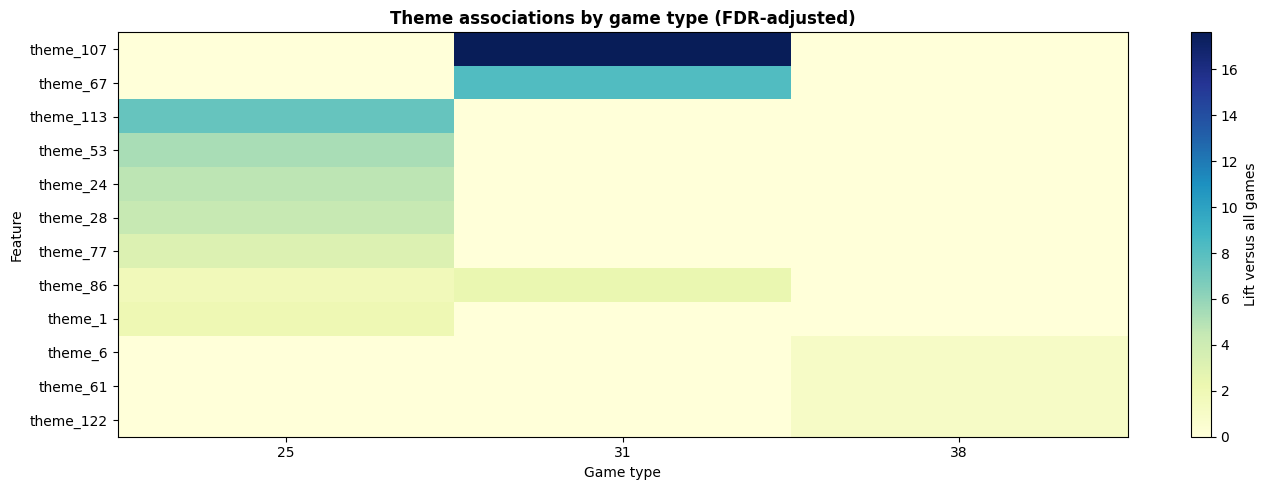

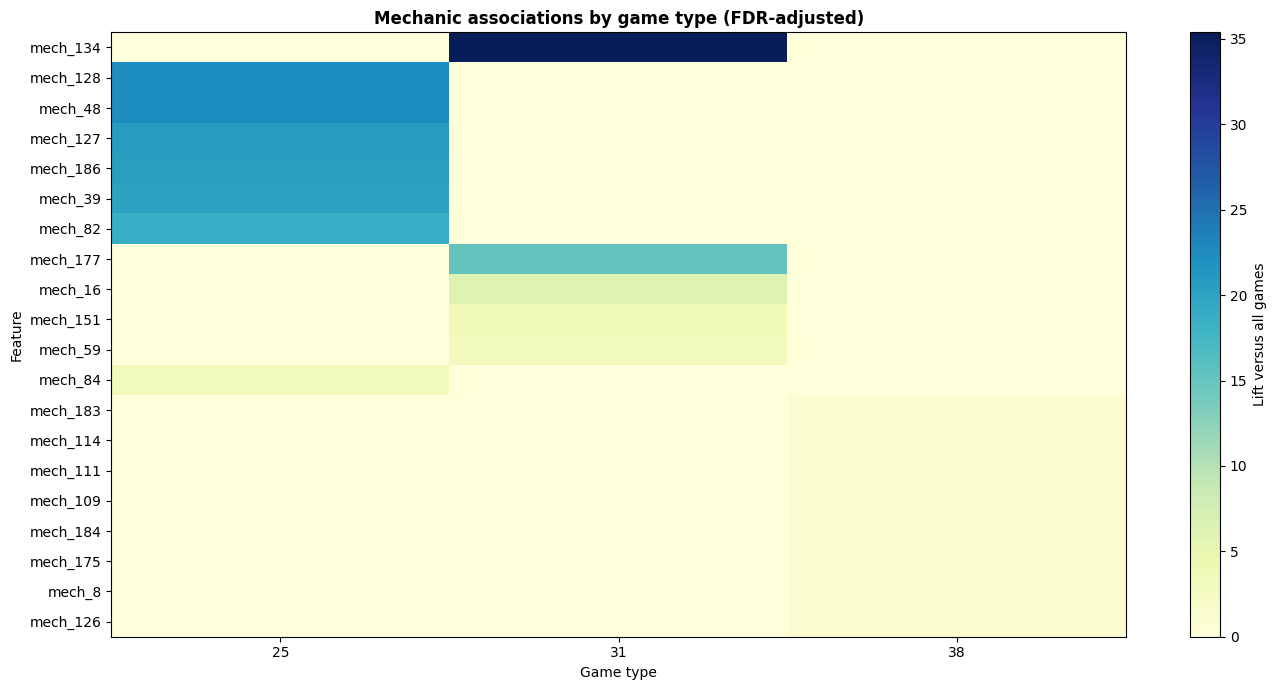

In [33]:
import matplotlib.pyplot as plt


def plot_significant_associations(associations, title, top_features=20):
    significant = associations[
        (associations["significant"]) & (associations["lift"] > 1)
    ].copy()
    if significant.empty:
        print(f"No positive FDR-significant associations found for {title.lower()}.")
        return

    selected_features = (
        significant.groupby("feature")["lift"].max()
        .nlargest(top_features)
        .index
    )
    heatmap_data = (
        significant[significant["feature"].isin(selected_features)]
        .pivot(index="feature", columns="game_type", values="lift")
        .fillna(0)
    )
    heatmap_data = heatmap_data.loc[
        heatmap_data.max(axis=1).sort_values(ascending=False).index
    ]

    figure, axis = plt.subplots(
        figsize=(14, max(5, len(heatmap_data) * 0.35))
    )
    image = axis.imshow(heatmap_data, cmap="YlGnBu", aspect="auto")
    axis.set_xticks(range(len(heatmap_data.columns)))
    axis.set_xticklabels(heatmap_data.columns)
    axis.set_yticks(range(len(heatmap_data.index)))
    axis.set_yticklabels(heatmap_data.index)
    axis.set_xlabel("Game type")
    axis.set_ylabel("Feature")
    axis.set_title(title, weight="bold")
    colorbar = figure.colorbar(image, ax=axis)
    colorbar.set_label("Lift versus all games")
    figure.tight_layout()
    plt.show()


theme_game_features, theme_associations = analyse_feature_associations(
    df, "theme_"
 )
mechanic_game_features, mechanic_associations = analyse_feature_associations(
    df, "mech_"
 )

print("FDR-significant theme associations")
display(
    theme_associations[theme_associations["significant"]]
    .sort_values(["lift", "p_value_fdr"], ascending=[False, True])
    .head(20)
    .round(3)
 )

print("FDR-significant mechanic associations")
display(
    mechanic_associations[mechanic_associations["significant"]]
    .sort_values(["lift", "p_value_fdr"], ascending=[False, True])
    .head(20)
    .round(3)
 )

plot_significant_associations(
    theme_associations, "Theme associations by game type (FDR-adjusted)"
 )
plot_significant_associations(
    mechanic_associations, "Mechanic associations by game type (FDR-adjusted)"
 )

## Theme Associations

**Investigative question:** Which themes are characteristic of each game type after controlling for unequal game-type sizes and multiple statistical tests?

This table ranks positive, FDR-significant theme associations by lift. A lift above 1 means the theme appears more often within the game type than across the eligible game population. Only game types with at least 20 games are included.

In [34]:
theme_associations[
    (theme_associations["significant"])
    & (theme_associations["lift"] > 1)
].sort_values(["lift", "p_value_fdr"], ascending=[False, True]).head(20).round(3)

,game_type,feature,games_in_type,games_with_feature,within_type_pct,overall_pct,lift,odds_ratio,p_value,p_value_fdr,significant,feature_type
139,31,theme_107,38,24,63.158,3.586,17.613,74.571,0.000,0.000,True,theme
111,31,theme_67,38,11,28.947,3.528,8.205,13.371,0.000,0.000,True,theme
67,25,theme_113,77,14,18.182,2.429,7.485,12.889,0.000,0.000,True,theme
26,25,theme_53,77,5,6.494,1.215,5.346,7.101,0.002,0.017,True,theme
10,25,theme_24,77,37,48.052,10.237,4.694,9.990,0.000,0.000,True,theme
13,25,theme_28,77,16,20.779,4.743,4.381,6.303,0.000,0.000,True,theme
42,25,theme_77,77,35,45.455,14.286,3.182,5.660,0.000,0.000,True,theme
125,31,theme_86,38,26,68.421,29.092,2.352,5.514,0.000,0.000,True,theme
0,25,theme_1,77,20,25.974,13.013,1.996,2.477,0.001,0.015,True,theme
50,25,theme_86,77,37,48.052,29.092,1.652,2.354,0.000,0.005,True,theme


## Theme Findings

- **Game type 31 has the strongest theme signature.** Theme_107 occurs in 63.2% of its 38 games, compared with 3.6% overall, giving a lift of 17.61. Theme_67 also appears disproportionately often, with an 8.21 lift.

- **Game type 25 has several distinct themes.** Theme_113 is present in 18.2% of its games versus 2.4% overall, while themes 24, 28, and 77 are also materially more common in this type.

- **Game type 38 shows only modest over-representation.** Its significant themes have lifts close to 1, which is expected because it contains most eligible games and therefore resembles the overall game population.

> The theme results show that game types 25 and 31 are differentiated by a small number of strongly over-represented themes, while the dominant game type 38 is closer to the portfolio baseline.

## Mechanic Associations

**Investigative question:** Which mechanics are characteristic of each game type after applying the same reliability and statistical-significance controls?

This table applies the same game-level Fisher-test and FDR-correction framework to mechanic flags. It identifies mechanics that occur more often in a game type than expected from the eligible game population.

In [35]:
mechanic_associations[
    (mechanic_associations["significant"])
    & (mechanic_associations["lift"] > 1)
].sort_values(["lift", "p_value_fdr"], ascending=[False, True]).head(20).round(3)

,game_type,feature,games_in_type,games_with_feature,within_type_pct,overall_pct,lift,odds_ratio,p_value,p_value_fdr,significant,feature_type
186,31,mech_134,38,35,92.105,2.603,35.389,1961.167,0.000,0.000,True,mech
25,25,mech_48,77,9,11.688,0.521,22.455,inf,0.000,0.000,True,mech
72,25,mech_128,77,6,7.792,0.347,22.455,inf,0.000,0.000,True,mech
71,25,mech_127,77,13,16.883,0.810,20.851,335.359,0.000,0.000,True,mech
102,25,mech_186,77,33,42.857,2.082,20.583,412.250,0.000,0.000,True,mech
19,25,mech_39,77,16,20.779,1.041,19.960,216.393,0.000,0.000,True,mech
46,25,mech_82,77,25,32.468,1.735,18.712,158.365,0.000,0.000,True,mech
206,31,mech_177,38,2,5.263,0.347,15.167,23.431,0.007,0.034,True,mech
117,31,mech_16,38,10,26.316,4.280,6.149,9.079,0.000,0.000,True,mech
195,31,mech_151,38,8,21.053,5.726,3.677,4.689,0.001,0.006,True,mech


## Mechanic Findings

- **Game type 31 has a highly distinctive mechanic profile.** Mechanic_134 appears in 92.1% of its 38 games but only 2.6% overall, producing a lift of 35.39.

- **Game type 25 also has several strongly associated mechanics.** Mechanics 48 and 128 have lifts of 22.46, while mechanics 127, 186, 39, and 82 are also substantially more prevalent than in the eligible game population.

- **The large game type 38 has statistically significant but small differences.** Its positive mechanic lifts are close to 1, so the practical distinction from the portfolio baseline is limited despite statistical significance.

> Mechanics provide sharper differentiation between game types 25 and 31 than the themes shown above, whereas game type 38 remains broadly representative of the overall portfolio.

## Selected Game-Type Profile

**Investigative question:** Which themes and mechanics are most characteristic of one selected game type?

This cell combines the validated theme and mechanic associations for a chosen game type. Change `selected_game_type` to inspect another eligible type. The output retains only positive, FDR-significant associations and shows their prevalence, lift, and adjusted p-value.

In [36]:
selected_game_type = 25

selected_associations = pd.concat(
    [theme_associations, mechanic_associations], ignore_index=True
 )
selected_associations = selected_associations[
    (selected_associations["game_type"] == selected_game_type)
    & (selected_associations["significant"])
    & (selected_associations["lift"] > 1)
 ].sort_values(["lift", "p_value_fdr"], ascending=[False, True])

print(f"Characteristic features for game type {selected_game_type}")
display(
    selected_associations[
        [
            "feature_type",
            "feature",
            "games_in_type",
            "games_with_feature",
            "within_type_pct",
            "overall_pct",
            "lift",
            "p_value_fdr",
        ]
    ].round(3)
 )

Characteristic features for game type 25


,feature_type,feature,games_in_type,games_with_feature,within_type_pct,overall_pct,lift,p_value_fdr
245,mech,mech_48,77,9,11.688,0.521,22.455,0.000
254,mech,mech_128,77,6,7.792,0.347,22.455,0.000
240,mech,mech_127,77,13,16.883,0.810,20.851,0.000
226,mech,mech_186,77,33,42.857,2.082,20.583,0.000
234,mech,mech_39,77,16,20.779,1.041,19.960,0.000
230,mech,mech_82,77,25,32.468,1.735,18.712,0.000
5,theme,theme_113,77,14,18.182,2.429,7.485,0.000
22,theme,theme_53,77,5,6.494,1.215,5.346,0.017
1,theme,theme_24,77,37,48.052,10.237,4.694,0.000
9,theme,theme_28,77,16,20.779,4.743,4.381,0.000


## Game Type 25 Profile: Findings

- **Game type 25 has 77 eligible games**, providing a more stable basis for interpretation than the small excluded game types.

- **Its clearest mechanic signals are mechanics 48 and 128.** They occur in 11.7% and 7.8% of game type 25 games respectively, compared with less than 1% overall; both have a lift of 22.46.

- **Mechanic_186 is the most prevalent characteristic mechanic.** It appears in 42.9% of game type 25 games, compared with 2.1% overall, giving a lift of 20.58.

- **Theme_113 is the strongest distinctive theme**, with a lift of 7.49. Themes 24, 28, and 77 are also more common in game type 25 than in the eligible portfolio.

> Overall, game type 25 has a coherent feature signature: a concentrated set of mechanics provides its strongest differentiation, supported by several over-represented themes.

In [ ]:
# 1. Identify all columns that start with either prefix
cols_to_drop = [col for col in df.columns if col.startswith('THEME_') or col.startswith('MECH_')]

# 2. Drop them from your DataFrame
df = df.drop(columns=cols_to_drop)
df['TOTALWAGER_BASE'] = df['TOTALWAGER'] * df['EXCHANGE_RATE_TO_BASE']
df['TOTALPAYOUT_BASE'] = df['TOTALPAYOUT'] * df['EXCHANGE_RATE_TO_BASE']
df = df.drop(columns=['TOTALWAGER','TOTALPAYOUT','EXCHANGE_RATE_TO_BASE'])
df.head()

In [ ]:
# Check skewness (Values > 1 mean highly right-skewed)
print(df[['TOTALSPINS', 'TOTALWAGER_BASE', 'TOTALPAYOUT_BASE']].skew())

In [ ]:
import pandas as pd
import scipy.stats as stats

# 1. Calculate the actual business performance per game type
summary = df.groupby('GAMETYPE').agg(
    Avg_Spins=('TOTALSPINS', 'median'),            # Median handles skew better than mean
    Avg_Wager_Base=('TOTALWAGER_BASE', 'median'),
    Total_GGR_Base=('TOTALWAGER_BASE', lambda x: x.sum() - df.loc[x.index, 'TOTALPAYOUT_BASE'].sum()),
    Player_Count=('PLAYERID', 'nunique')
).reset_index()

print("--- Business Performance by Game Type ---")
print(summary)

# 2. Run a Kruskal-Wallis test to prove if GAMETYPE significantly impacts wagers
# This groups raw wager arrays by gametype to test if their distributions differ
groups = [group['TOTALWAGER_BASE'].values for name, group in df.groupby('GAMETYPE')]
stat, p_value = stats.kruskal(*groups)

print("\n--- Statistical Significance ---")
print(f"Kruskal-Wallis p-value: {p_value:.5f}")
if p_value < 0.05:
    print("Result: SIGNIFICANT. Different game types attract completely different staking behaviors.")
else:
    print("Result: NOT SIGNIFICANT. Game types perform statistically the same.")


In [ ]:
import pandas as pd

# 1. Filter the dataset for the two high-risk game types
df_risk = df[df['GAMETYPE'].isin([7, 25])].copy()

# 2. Calculate Gross Gaming Revenue (GGR) at the individual game level
# GGR = Total Wager - Total Payout
df_risk['GGR_BASE'] = df_risk['TOTALWAGER_BASE'] - df_risk['TOTALPAYOUT_BASE']

# 3. Group by GAMEID and GAMETYPE to pinpoint the exact culprits
game_breakdown = df_risk.groupby(['GAMETYPE', 'GAMEID']).agg(
    Total_Wager_Base=('TOTALWAGER_BASE', 'sum'),
    Total_Payout_Base=('TOTALPAYOUT_BASE', 'sum'),
    Net_GGR_Base=('GGR_BASE', 'sum'),
    Unique_Players=('PLAYERID', 'nunique'),
    Total_Spins=('TOTALSPINS', 'sum')
).reset_index()

# 4. Sort by Net_GGR_Base ascending to put the largest multi-billion unit losses at the top
game_breakdown = game_breakdown.sort_values(by='Net_GGR_Base', ascending=True)

print("--- Top 10 Game IDs Driving Financial Outliers ---")
print(game_breakdown.head(10).to_string(index=False))


In [ ]:
# 1. Filter for the top outlier game IDs identified in this run
target_games = [5904, 4599, 5501, 5713]
df_outliers = df[df['GAMEID'].isin(target_games)].copy()

# 2. Group by Game and Player to find extreme payouts
player_exposure = df_outliers.groupby(['GAMEID', 'PLAYERID']).agg(
    Wager_Base=('TOTALWAGER_BASE', 'sum'),
    Payout_Base=('TOTALPAYOUT_BASE', 'sum'),
    Spins=('TOTALSPINS', 'sum')
).reset_index()

# 3. Calculate individual Return to Player (RTP) percentage
player_exposure['PLAYER_RTP'] = (player_exposure['Payout_Base'] / player_exposure['Wager_Base']) * 100

# 4. Display the top 10 highest-paying player accounts across these games
print(player_exposure.sort_values(by='Payout_Base', ascending=False).head(10).to_string(index=False))


In [ ]:
import pandas as pd
import numpy as np

def run_gametype_risk_engine(df, rtp_threshold=130.0, min_spins_threshold=1000):
    """
    Identifies high-risk player sessions and maps them back to their operational GAMETYPE,
    including cumulative spin metrics.
    """
    
    # 1. Aggregate at the unique GAMETYPE + GAMEID + PLAYERID level
    risk_engine = df.groupby(['GAMETYPE', 'GAMEID', 'PLAYERID']).agg(
        Total_Wager_Base=('TOTALWAGER_BASE', 'sum'),
        Total_Payout_Base=('TOTALPAYOUT_BASE', 'sum'),
        Total_Spins=('TOTALSPINS', 'sum')
    ).reset_index()
    
    # 2. Calculate the Player Return to Player (RTP) Percentage
    risk_engine['PLAYER_RTP'] = np.where(
        risk_engine['Total_Wager_Base'] > 0,
        (risk_engine['Total_Payout_Base'] / risk_engine['Total_Wager_Base']) * 100,
        0.0
    )
    
    # 3. Calculate absolute financial house exposure
    risk_engine['Net_House_Loss'] = risk_engine['Total_Payout_Base'] - risk_engine['Total_Wager_Base']
    
    # 4. Filter for high-volume, high-yield outliers
    alerts = risk_engine[
        (risk_engine['PLAYER_RTP'] >= rtp_threshold) & 
        (risk_engine['Total_Spins'] >= min_spins_threshold)
    ].copy()
    
    # 5. Group by GAMETYPE to summarize the platform exposure profile (with Spin Data added)
    gametype_exposure = alerts.groupby('GAMETYPE').agg(
        Triggered_Alerts=('PLAYERID', 'count'),
        Total_Exposure_Loss=('Net_House_Loss', 'sum'),
        Max_Player_RTP=('PLAYER_RTP', 'max'),
        Impacted_Games=('GAMEID', 'nunique'),
        Total_Spins_Risked=('Total_Spins', 'sum'),                     # <-- Total Spins added
        Avg_Spins_Per_Alert=('Total_Spins', 'mean')                     # <-- Average Spins added
    ).reset_index().sort_values(by='Total_Exposure_Loss', ascending=False)
    
    print("--- 📊 SYSTEM PROFILE: EXPOSURE BY GAMETYPE (WITH SPINS) ---")
    return gametype_exposure

# Execute the multi-level engine
gametype_summary = run_gametype_risk_engine(df)
print(gametype_summary.to_string(index=False))
